          Brand           Model         Year Country Condition  Engine_Size  \
count      5000            5000  5000.000000    5000      5000  5000.000000   
unique       10              10          NaN       3         4          NaN   
top     Ferrari  M4 Competition          NaN    Asia       new          NaN   
freq        533             538          NaN    1677      2559          NaN   
mean        NaN             NaN  2001.904800     NaN       NaN     4.828700   
std         NaN             NaN    12.873697     NaN       NaN     1.858353   
min         NaN             NaN  1980.000000     NaN       NaN     1.600000   
25%         NaN             NaN  1991.000000     NaN       NaN     3.200000   
50%         NaN             NaN  2002.000000     NaN       NaN     4.800000   
75%         NaN             NaN  2013.000000     NaN       NaN     6.500000   
max         NaN             NaN  2024.000000     NaN       NaN     8.000000   

         Horsepower       Torque       Weight    To

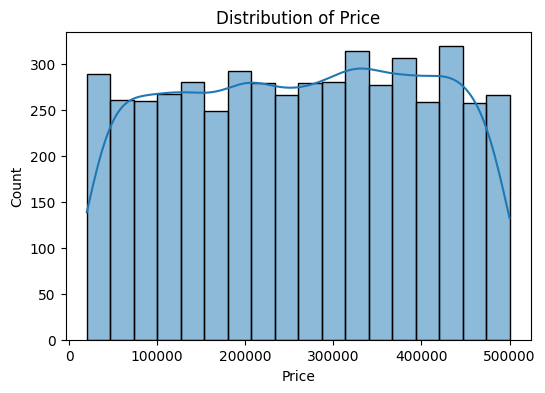

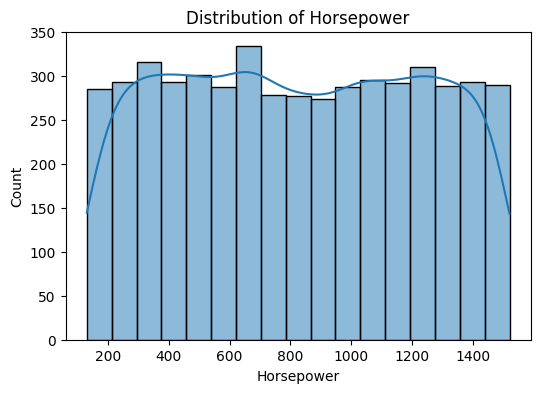

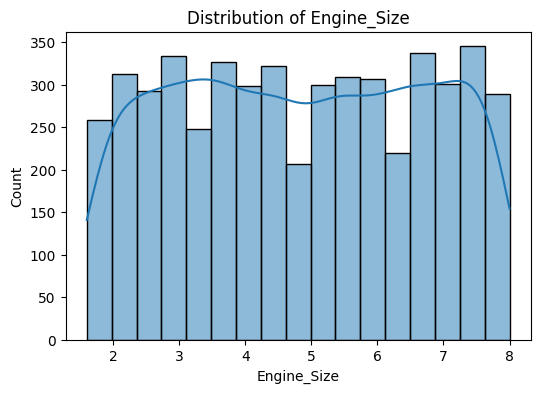

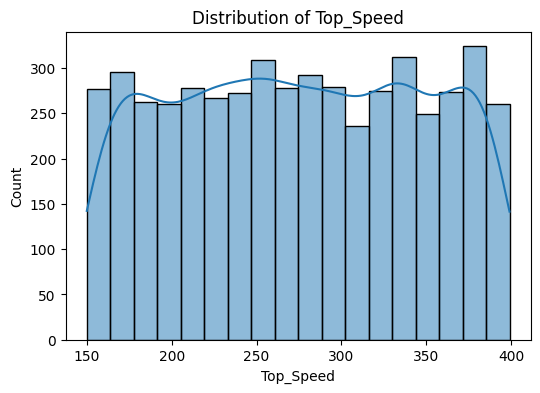

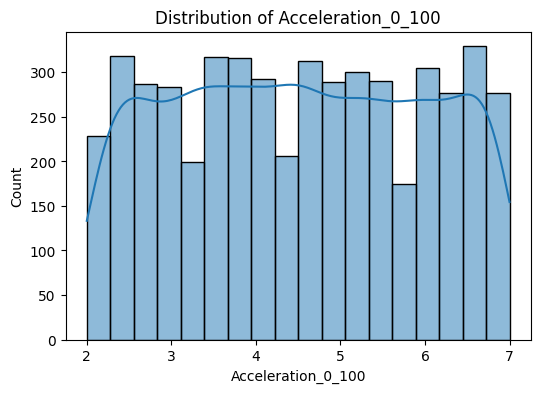

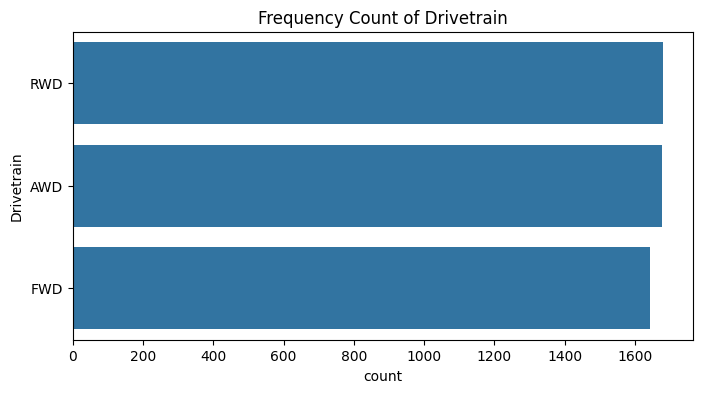

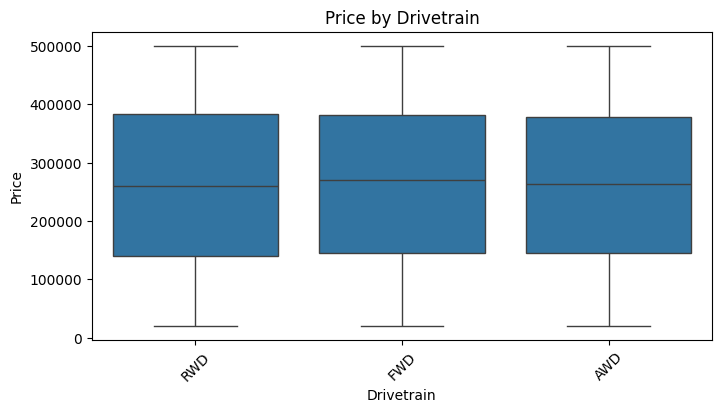

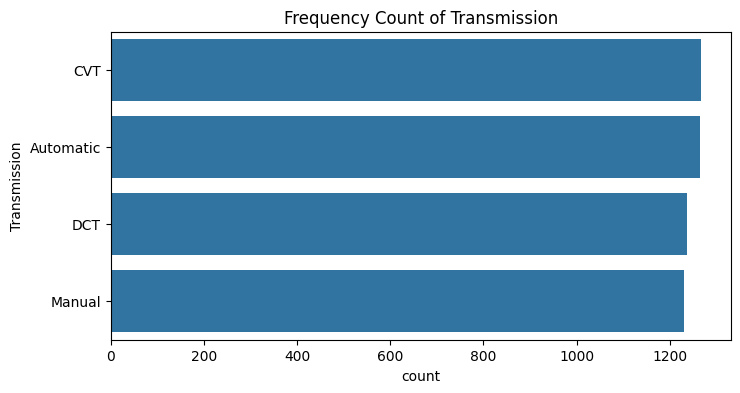

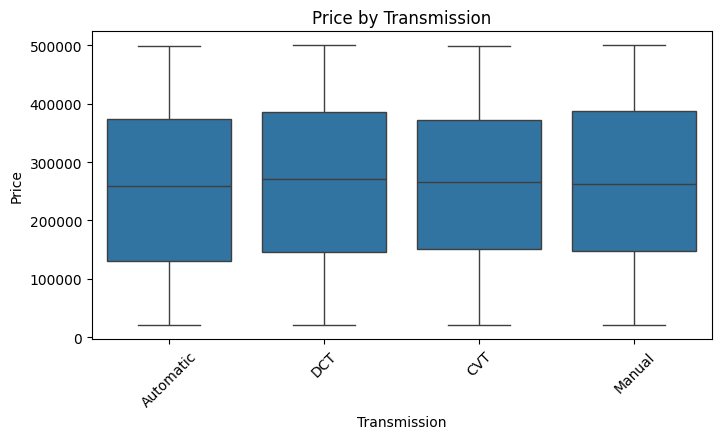

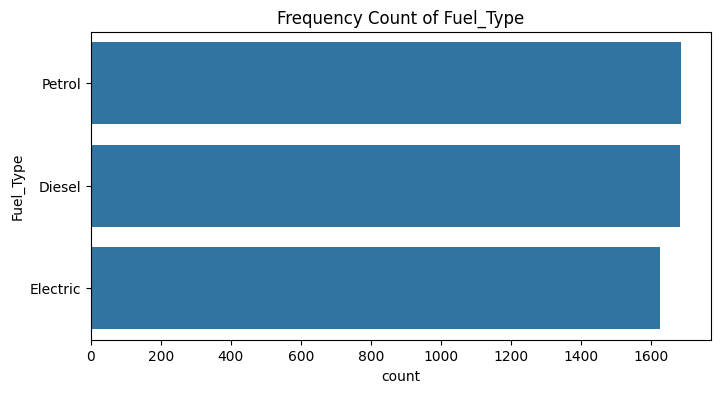

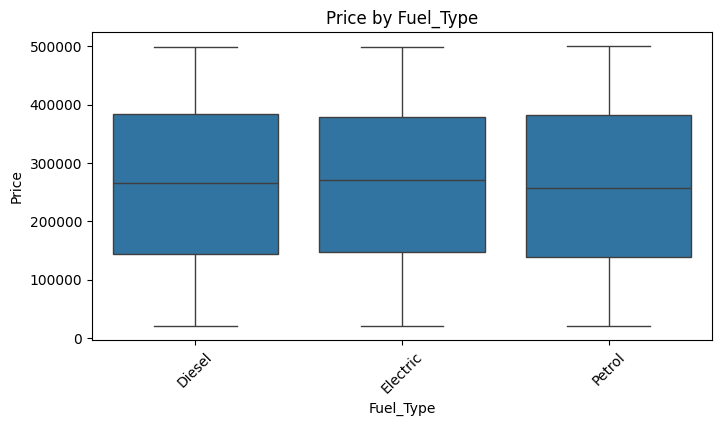

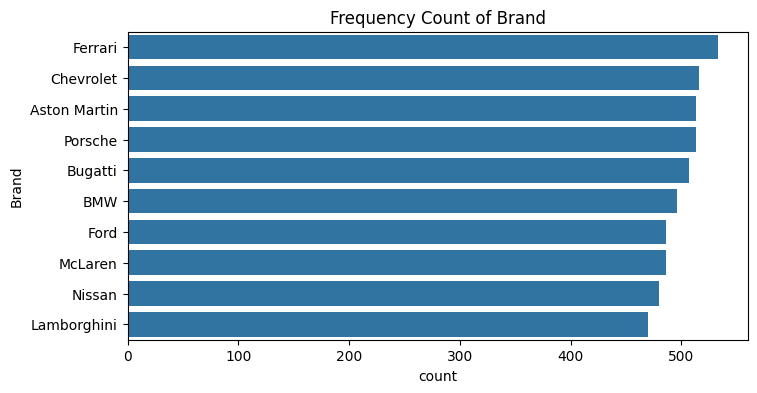

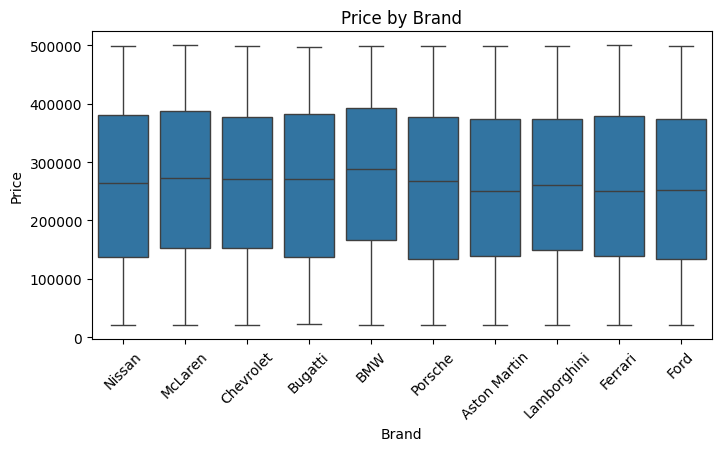

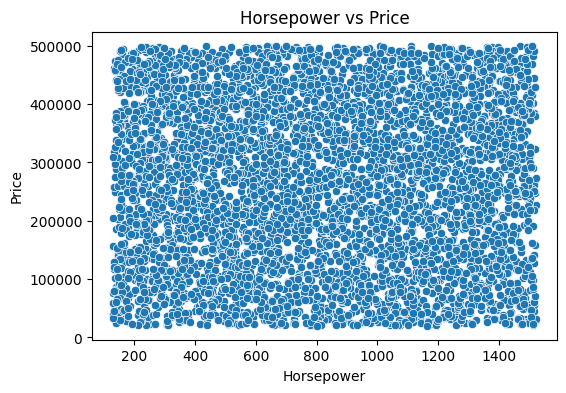

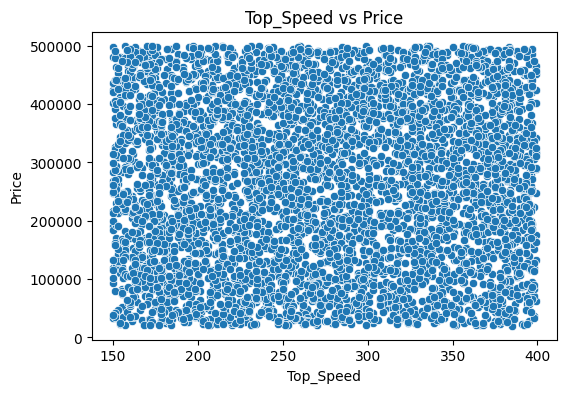

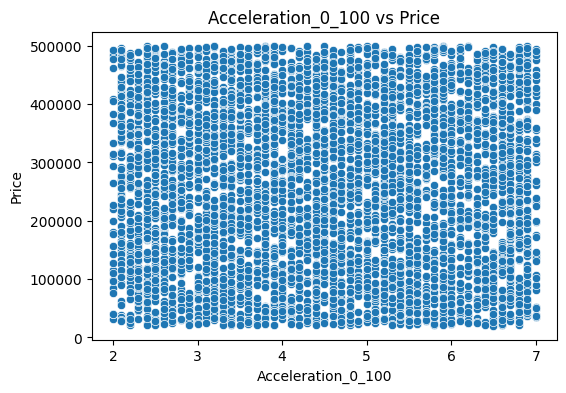

Correlation matrix:
                        Price  Horsepower  Engine_Size  Top_Speed  \
Price               1.000000    0.006633    -0.008207   0.029831   
Horsepower          0.006633    1.000000    -0.000809   0.016573   
Engine_Size        -0.008207   -0.000809     1.000000   0.005796   
Top_Speed           0.029831    0.016573     0.005796   1.000000   
Acceleration_0_100 -0.011925   -0.011268     0.021086  -0.012106   

                    Acceleration_0_100  
Price                        -0.011925  
Horsepower                   -0.011268  
Engine_Size                   0.021086  
Top_Speed                    -0.012106  
Acceleration_0_100            1.000000  


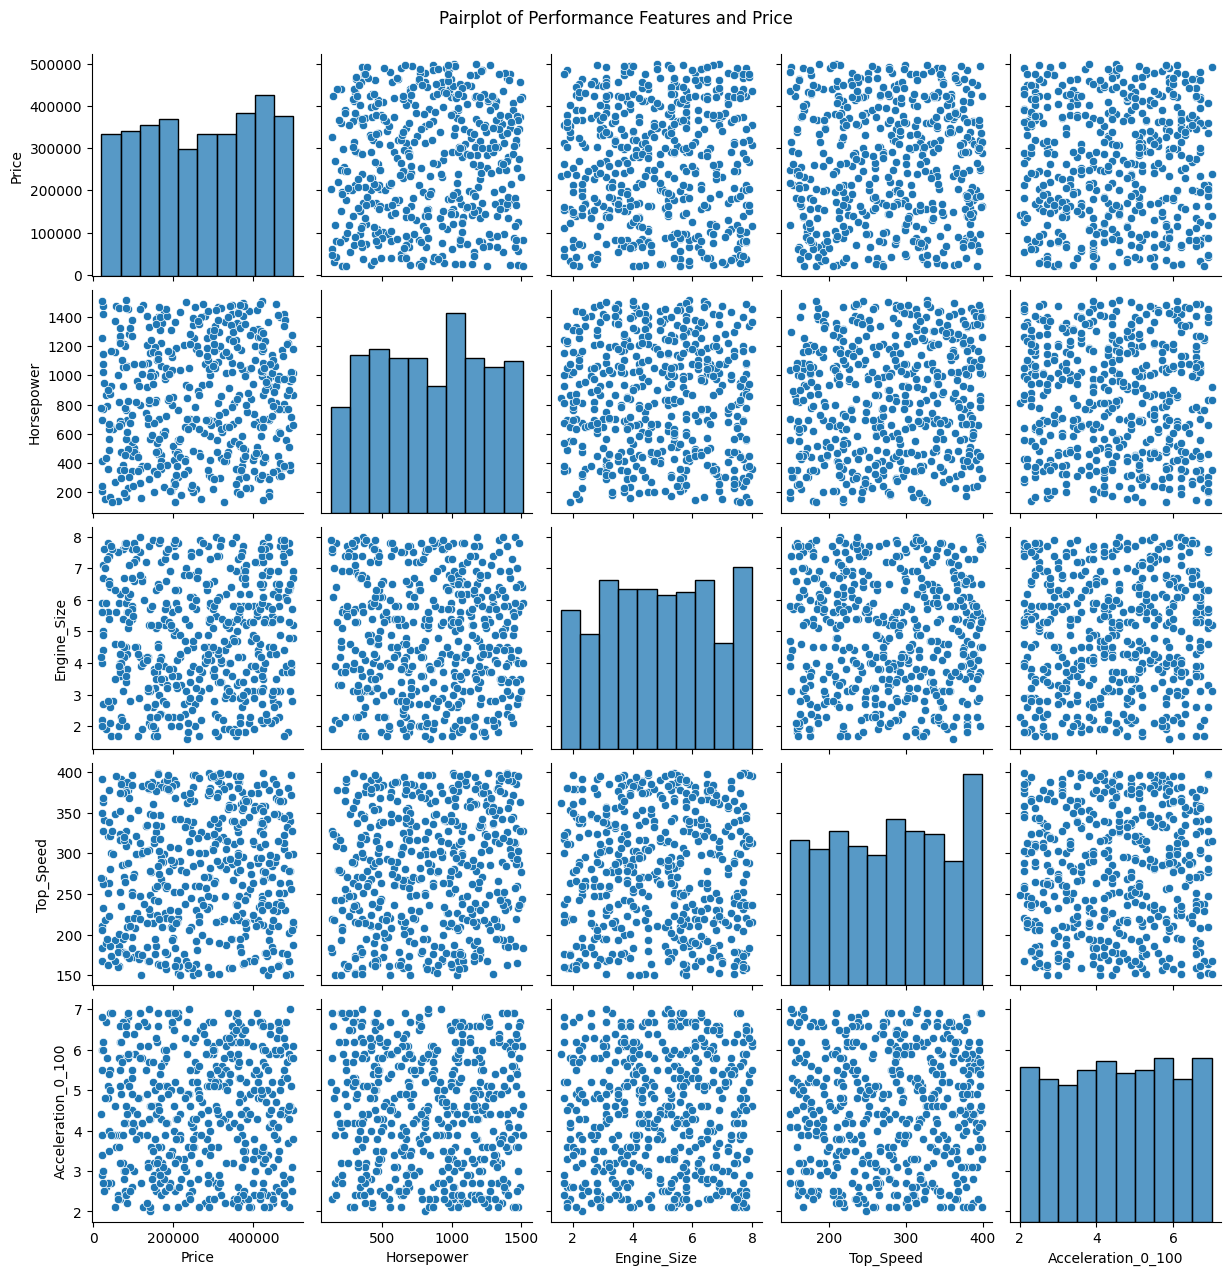

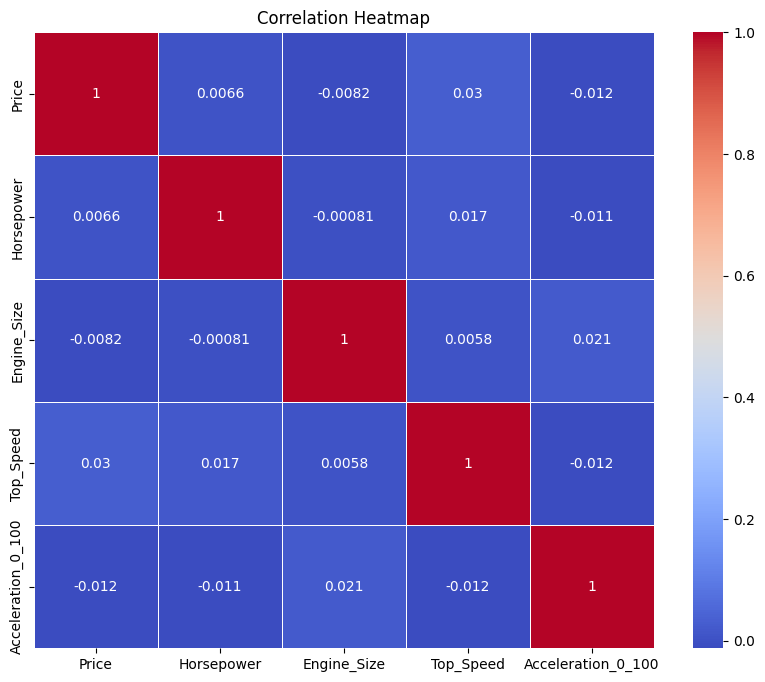

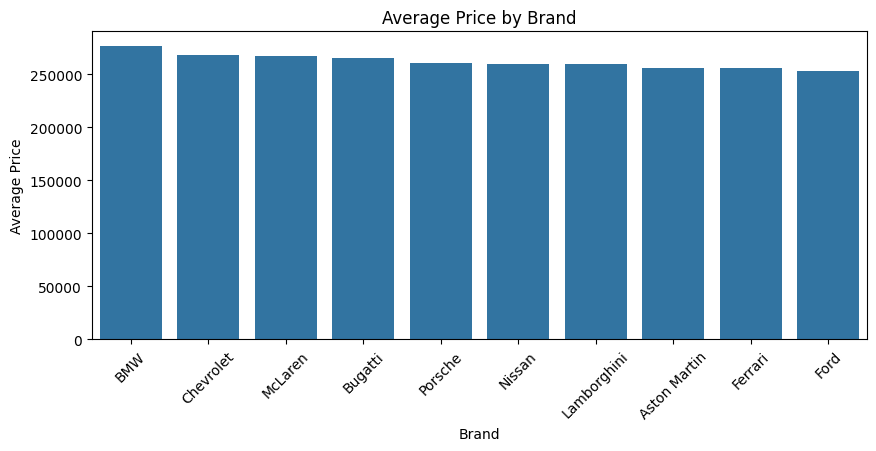

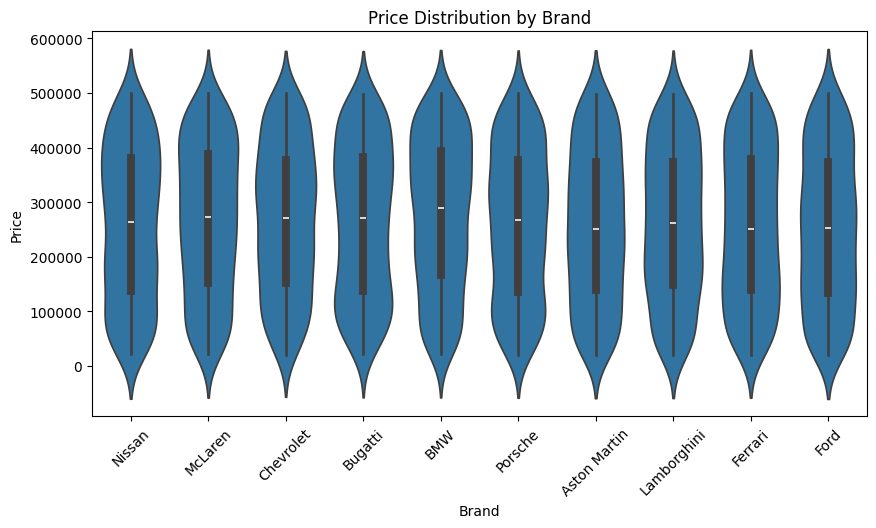

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Elite Sports Cars in Data.csv')
print(df.describe(include='all'))

num_features = ['Price', 'Horsepower', 'Engine_Size', 'Top_Speed', 'Acceleration_0_100']

for col in num_features:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()

if 'Drivetrain_FWD' in df.columns and 'Drivetrain_RWD' in df.columns:
    df['Drivetrain'] = np.where(df['Drivetrain_FWD'] == 1, 'FWD',
                         np.where(df['Drivetrain_RWD'] == 1, 'RWD', 'AWD/Other'))


trans_cols = [c for c in df.columns if c.startswith("Transmission_")]
if trans_cols:
    df['Transmission'] = df[trans_cols].idxmax(axis=1).str.replace("Transmission_", "")

fuel_cols = [c for c in df.columns if c.startswith("Fuel_Type_")]
if fuel_cols:
    df['Fuel_Type'] = df[fuel_cols].idxmax(axis=1).str.replace("Fuel_Type_", "")


brand_cols = [c for c in df.columns if c.startswith("Brand_")]
if brand_cols:
    df['Brand'] = df[brand_cols].idxmax(axis=1).str.replace("Brand_", "")


model_cols = [c for c in df.columns if c.startswith("Model_")]
if model_cols:
    df['Model'] = df[model_cols].idxmax(axis=1).str.replace("Model_", "")

cat_features = ['Drivetrain', 'Transmission', 'Fuel_Type', 'Brand']

for col in cat_features:
    if col in df.columns:
        plt.figure(figsize=(8,4))
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f'Frequency Count of {col}')
        plt.show()


        plt.figure(figsize=(8,4))
        sns.boxplot(y=df['Price'], x=df[col])
        plt.title(f'Price by {col}')
        plt.xticks(rotation=45)
        plt.show()


for col in ['Horsepower', 'Top_Speed', 'Acceleration_0_100']:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df['Price'])
        plt.title(f'{col} vs Price')
        plt.show()


pairplot_features = list(dict.fromkeys(num_features + ['Price']))
correlations = df[pairplot_features].corr()
print('Correlation matrix:\n', correlations)


if len(df) > 500:
    sns.pairplot(df[pairplot_features].sample(500, random_state=42))
else:
    sns.pairplot(df[pairplot_features])
plt.suptitle('Pairplot of Performance Features and Price', y=1.02)
plt.show()


plt.figure(figsize=(10,8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


if 'Brand' in df.columns:
    brand_price = df.groupby('Brand')['Price'].mean().sort_values(ascending=False)
    plt.figure(figsize=(10,4))
    sns.barplot(x=brand_price.index, y=brand_price.values)
    plt.title('Average Price by Brand')
    plt.xlabel('Brand')
    plt.ylabel('Average Price')
    plt.xticks(rotation=45)
    plt.show()


    plt.figure(figsize=(10,5))
    sns.violinplot(x='Brand', y='Price', data=df)
    plt.title('Price Distribution by Brand')
    plt.xticks(rotation=45)
    plt.show()



In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, SGDRegressor

# =========================
# 1) Load data
# =========================
df = pd.read_csv('elite_supercars_cleaned.csv')

# Choose target
TARGET = 'Price'        # or 'Log_Price'
y = df[TARGET].values

# Split features into numerical and categorical
# Adjust these lists to match your dataset
numeric_cols = [
    'Engine_Size','Horsepower','Torque','Top_Speed','Acceleration_0_100',
    'Fuel_Efficiency','CO2_Emissions','Mileage','Safety_Rating','Insurance_Cost','Year'
]
categorical_cols = [c for c in df.columns if c not in numeric_cols + [TARGET] and df[c].dtype == 'uint8' or df[c].dtype == 'int64' and c.startswith(('Brand_', 'Model_', 'Transmission_', 'Drivetrain_', 'Fuel_Type_'))]

# If your cleaned dataset already contains one-hot columns, categorical_cols can be left empty.
# Otherwise, detect raw categoricals like this:
raw_cats = [c for c in df.columns if df[c].dtype == 'object' and c != TARGET]
if raw_cats:
    categorical_cols = raw_cats

# Feature matrix
X = df.drop(columns=[TARGET])

# =========================
# 2) Train/Test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 3) Preprocessing
# =========================
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# If raw categorical columns exist, one-hot encode; if already one-hot, pass-through
if raw_cats:
    categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
else:
    categorical_transformer = 'passthrough'

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, [c for c in numeric_cols if c in X.columns]),
        ('cat', categorical_transformer, [c for c in categorical_cols if c in X.columns])
    ],
    remainder='drop'
)

# =========================
# 4) Define models
# =========================
models = {
    'LinearRegression': Pipeline([
        ('prep', preprocess),
        ('mdl', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('prep', preprocess),
        ('mdl', Ridge(alpha=10.0, random_state=42))
    ]),
    'Lasso': Pipeline([
        ('prep', preprocess),
        ('mdl', Lasso(alpha=0.001, random_state=42, max_iter=10000))
    ]),
    'ElasticNet': Pipeline([
        ('prep', preprocess),
        ('mdl', ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=10000))
    ]),
    'HuberRegressor': Pipeline([
        ('prep', preprocess),
        ('mdl', HuberRegressor(epsilon=1.35))
    ]),
    'SGDRegressor': Pipeline([
        ('prep', preprocess),
        ('mdl', SGDRegressor(loss='huber', alpha=1e-4, max_iter=2000, random_state=42))
    ]),
    'Poly2+Linear': Pipeline([
        ('prep', preprocess),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('mdl', LinearRegression())
    ])
}

# =========================
# 5) Cross-validation
# =========================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_metrics(pipeline, X, y):
    # R2
    r2 = cross_val_score(pipeline, X, y, scoring='r2', cv=cv, n_jobs=-1)
    # Negative MAE, RMSE
    nmae = cross_val_score(pipeline, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
    nrmse = cross_val_score(pipeline, X, y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    return {
        'R2_mean': r2.mean(), 'R2_std': r2.std(),
        'MAE_mean': -nmae.mean(), 'MAE_std': nmae.std(),
        'RMSE_mean': -nrmse.mean(), 'RMSE_std': nrmse.std()
    }

results = []
for name, pipe in models.items():
    m = cv_metrics(pipe, X_train, y_train)
    m['Model'] = name
    results.append(m)

res_df = pd.DataFrame(results).sort_values(by='R2_mean', ascending=False)
print(res_df[['Model','R2_mean','MAE_mean','RMSE_mean']])

# Save metrics for reporting
res_df.to_csv('linear_models_cv_metrics.csv', index=False)

# =========================
# 6) Select best model and evaluate on test set
# =========================
best_name = res_df.iloc[0]['Model']
best_model = models[best_name]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) # removed squared=False argument

print(f'Best CV model: {best_name}')
print(f'Test R2: {r2:.4f}')
print(f'Test MAE: {mae:.4f}')
print(f'Test RMSE: {rmse:.4f}')

# =========================
# 7) Save the trained model
# =========================
import joblib
joblib.dump(best_model, f'best_linear_model_{best_name}.pkl')
print('Saved:', f'best_linear_model_{best_name}.pkl')

              Model   R2_mean  MAE_mean  RMSE_mean
2             Lasso -0.007460  0.867077   1.003541
3        ElasticNet -0.007844  0.867164   1.003732
1             Ridge -0.008204  0.867264   1.003911
0  LinearRegression -0.008353  0.867310   1.003985
5      SGDRegressor -0.008574  0.867600   1.004100
4    HuberRegressor -0.012837  0.868366   1.006209
6      Poly2+Linear -0.071918  0.884072   1.035119
Best CV model: Lasso
Test R2: -0.0084
Test MAE: 0.8706
Test RMSE: 1.0071
Saved: best_linear_model_Lasso.pkl


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Lasso
import joblib

# ========= 1) Load =========
df = pd.read_csv('elite_supercars_cleaned.csv')

# Choose target
USE_LOG_TARGET = False            # set True to try log target
TARGET = 'Price' if not USE_LOG_TARGET else 'Log_Price'
y = df[TARGET].values
X = df.drop(columns=[TARGET])

# Identify columns
num_cols = [c for c in X.columns if np.issubdtype(X[c].dtype, np.number)]
cat_cols = [c for c in X.columns if X[c].dtype == 'object']

# ========= 2) Split =========
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ========= 3) Preprocess =========
numeric_tf = Pipeline([('scaler', StandardScaler())])
categorical_tf = OneHotEncoder(handle_unknown='ignore', sparse_output=False) if cat_cols else 'passthrough'

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_tf, num_cols),
        ('cat', categorical_tf, cat_cols)
    ],
    remainder='drop'
)

# ========= 4) Model + Grid =========
pipe = Pipeline([
    ('prep', preprocess),
    ('mdl', Lasso(max_iter=10000, random_state=42))
])

param_grid = {
    'mdl__alpha': np.logspace(-4, 1, 12)  # 0.0001 to 10
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(
    pipe, param_grid,
    scoring='r2', cv=cv, n_jobs=-1, refit=True, verbose=1
)

# ========= 5) Fit & Evaluate =========
gs.fit(X_train, y_train)
best_lasso = gs.best_estimator_

print('Best alpha:', gs.best_params_['mdl__alpha'])
print('CV best R2:', gs.best_score_)

y_pred = best_lasso.predict(X_test)

# If using log target, back-transform for human-scale errors (optional report)
if USE_LOG_TARGET:
    # assuming Log_Price = log(Price + 1)
    y_pred_price = np.expm1(y_pred)
    y_test_price = np.expm1(y_test)
    r2 = r2_score(y_test, y_pred)              # R2 in log-space
    mae = mean_absolute_error(y_test_price, y_pred_price)
    rmse = mean_squared_error(y_test_price, y_pred_price)
    print(f'Test R2 (log-space): {r2:.4f}')
    print(f'Test MAE (price): {mae:.4f}')
    print(f'Test RMSE (price): {rmse:.4f}')
else:
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    print(f'Test R2: {r2:.4f}')
    print(f'Test MAE: {mae:.4f}')
    print(f'Test RMSE: {rmse:.4f}')

# ========= 6) Refit on full data =========
best_lasso.fit(X, y)

# ========= 7) Save artifacts =========
joblib.dump(best_lasso, 'lasso_price_pipeline.pkl')
pd.DataFrame({
    'alpha': [gs.best_params_['mdl__alpha']],
    'cv_best_r2': [gs.best_score_],
    'test_r2': [r2],
    'test_mae': [mae],
    'test_rmse': [rmse],
    'log_target_used': [USE_LOG_TARGET]
}).to_csv('lasso_results.csv', index=False)

print('Saved model: lasso_price_pipeline.pkl')
print('Saved metrics: lasso_results.csv')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best alpha: 0.006579332246575682
CV best R2: 0.8796238156690421
Test R2: 0.8769
Test MAE: 0.2943
Test RMSE: 0.1229
Saved model: lasso_price_pipeline.pkl
Saved metrics: lasso_results.csv
